# L2 matchups with PACE data -- RRS

* Create a plan for files to use `pc.plan()`
* Print the plan to check it `print(plan.summary())`
* Do the plan and get matchups `pc.matchup(plan)`

## Prerequisite -- Login to EarthData

The examples here use NASA EarthData and you need to have an account with EarthData. Make sure you can login.

In [5]:
import earthaccess
earthaccess.login()

In [6]:
import earthaccess
results = earthaccess.search_datasets(instrument="oci")

short_names = [
    item.summary()["short-name"]
    for item in results
    if "L2" in item.summary()["short-name"]
]

print(short_names)

['PACE_OCI_L2_UVAI_UAA_NRT', 'PACE_OCI_L2_UVAI_UAA', 'PACE_OCI_L2_AER_UAA_NRT', 'PACE_OCI_L2_AER_UAA', 'PACE_OCI_L2_AOP_NRT', 'PACE_OCI_L2_AOP', 'PACE_OCI_L2_CLOUD_MASK_NRT', 'PACE_OCI_L2_CLOUD_MASK', 'PACE_OCI_L2_CLOUD_NRT', 'PACE_OCI_L2_CLOUD', 'PACE_OCI_L2_LANDVI_NRT', 'PACE_OCI_L2_LANDVI', 'PACE_OCI_L2_BGC_NRT', 'PACE_OCI_L2_BGC', 'PACE_OCI_L2_IOP_NRT', 'PACE_OCI_L2_IOP', 'PACE_OCI_L2_PAR_NRT', 'PACE_OCI_L2_PAR', 'PACE_OCI_L2_SFREFL_NRT', 'PACE_OCI_L2_SFREFL', 'PACE_OCI_L2_TRGAS_NRT', 'PACE_OCI_L2_TRGAS']


In [61]:
# bounding_box = (lon_min, lat_min, lon_max, lat_max)
import earthaccess
results = earthaccess.search_data(
    short_name = 'PACE_OCI_L2_AOP',
    temporal = ("2024-06-13", "2024-06-13"),
#    bounding_box = (-82.8, 27.38, -82.5, 27.3835)
)
len(results)

147

In [62]:
import json
from pathlib import Path

out = Path("/home/jovyan/earthaccess_matchup/examples/fixtures/earthaccess_results_l2.json")

samples = []
for r in results:
    d = getattr(r, "data", None)
    if d is None:
        d = r.__dict__
    samples.append(d)

out.write_text(json.dumps(samples, indent=2, default=str))
print("wrote:", out.resolve())


wrote: /home/jovyan/earthaccess_matchup/examples/fixtures/earthaccess_results_l2.json


In [48]:
[res.data_links() for res in results]

[['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240613T184939.L2.OC_AOP.V3_1.nc']]

In [53]:
import xarray as xr
ds = xr.open_dataset("fixtures/PACE_OCI.20240613T171620.L2.OC_AOP.V3_1.nc")
ds

<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
Attributes: (12/47)
    title:                             OCI Level-2 Data AOP
    product_name:                      PACE_OCI.20240613T171620.L2.OC_AOP.V3_...
    processing_version:                3.1
    history:                           l2gen par=/data12/sdpsoper/vdc/vpu31/w...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_min:                -90.615036
    startDirection:                    Ascending
    endDirection:                      Ascending
    day_night_flag:                    Day
    earth_sun_distance_correction:     0.9694162011146545
    geospatial_bounds:                 POLYGON ((-56.46700 49.14474, -90.6150...

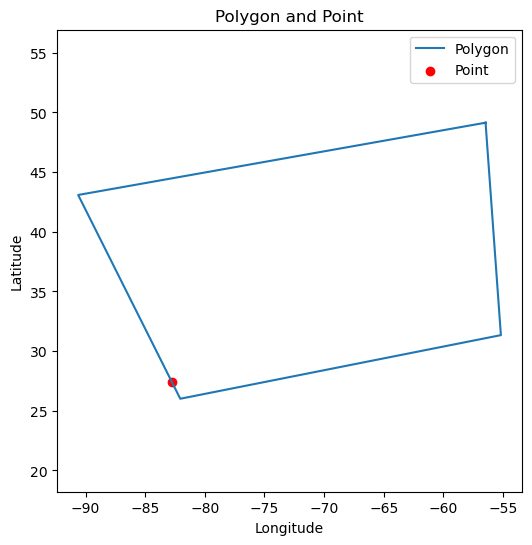

In [54]:
from shapely import wkt
import matplotlib.pyplot as plt

# polygon from your metadata
poly_wkt = """
POLYGON ((-56.46700 49.14474,
          -90.61504 43.08701,
          -82.05746 26.00619,
          -55.18192 31.33828,
          -56.46700 49.14474))
"""

polygon = wkt.loads(poly_wkt)

# point
lon, lat = -82.7375, 27.3835

# extract polygon coordinates
x, y = polygon.exterior.xy

plt.figure(figsize=(6,6))
plt.plot(x, y, label="Polygon")
plt.scatter(lon, lat, color="red", label="Point")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.title("Polygon and Point")
plt.axis("equal")

plt.show()

In [55]:
from shapely import wkt
from shapely.geometry import Point

poly_wkt = """
POLYGON ((-56.46700 49.14474,
          -90.61504 43.08701,
          -82.05746 26.00619,
          -55.18192 31.33828,
          -56.46700 49.14474))
"""

polygon = wkt.loads(poly_wkt)

point = Point(-82.7375, 27.3835)

polygon.contains(point)

True

## Load some points

In [35]:
from pathlib import Path
import earthaccess
import point_collocation as pc
import pandas as pd

HERE = Path.cwd()
POINTS_CSV = HERE / "fixtures" / "points.csv"
df_points = pd.read_csv(POINTS_CSV)  # lat, lon, date columns
print(len(df_points))
df_points.head()

595


,lat,lon,date
0,27.3835,-82.7375,2024-06-13
1,27.1190,-82.7125,2024-06-14
2,26.9435,-82.8170,2024-06-14
3,26.6875,-82.8065,2024-06-14
4,26.6675,-82.6455,2024-06-14


In [26]:
df_points.lon.min()

np.float64(-97.243)

## Get a plan for matchups from PACE data

In [64]:
%%time
# bounding_box = (lon_min, lat_min, lon_max, lat_max)
import point_collocation as pc
plan = pc.plan(
    df_points[0:1], # -82.7375, 27.3835	
    data_source="earthaccess",
    source_kwargs={
        "short_name": "PACE_OCI_L2_AOP",
#        "bounding_box": (-97.3, 24.6, -81.5, 30.39)
    },
    time_buffer="12h"
)

CPU times: user 27.8 ms, sys: 0 ns, total: 27.8 ms
Wall time: 8.98 s


In [60]:
plan.summary()

Plan: 1 points → 7 unique granule(s)
  Points with 0 matches : 0
  Points with >1 matches: 1
  Time buffer: 0 days 12:00:00

First 1 point(s):
  [0] lat=27.3835, lon=-82.7375, time=2024-06-13 12:00:00: 7 match(es)
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240613T004810.L2.OC_AOP.V3_1.nc
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240613T005310.L2.OC_AOP.V3_1.nc
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240613T171620.L2.OC_AOP.V3_1.nc
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240613T184939.L2.OC_AOP.V3_1.nc
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240613T185439.L2.OC_AOP.V3_1.nc
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240613T234436.L2.OC_AOP.V3_1.nc
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240613T234936

In [41]:
plan.show_variables()

Dimensions : {}
Variables  : []


## Get the matchups using that plan

In [3]:
res = pc.matchup(plan, variables=["Rrs"])

In [8]:
res

,lat,lon,time,granule_id,Rrs_346,Rrs_348,Rrs_351,Rrs_353,Rrs_356,Rrs_358,...,Rrs_706,Rrs_707,Rrs_708,Rrs_709,Rrs_711,Rrs_712,Rrs_713,Rrs_714,Rrs_717,Rrs_719
0,27.3835,-82.7375,2024-06-13 12:00:00,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,27.1190,-82.7125,2024-06-14 12:00:00,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,26.9435,-82.8170,2024-06-14 12:00:00,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,26.6875,-82.8065,2024-06-14 12:00:00,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,26.6675,-82.6455,2024-06-14 12:00:00,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,26.8985,-82.6710,2024-06-14 12:00:00,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,26.8965,-82.5660,2024-06-14 12:00:00,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,26.8925,-82.4220,2024-06-14 12:00:00,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,26.7135,-82.4535,2024-06-14 12:00:00,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,26.5020,-82.3010,2024-06-14 12:00:00,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## How long does it take?

In [8]:
%%time
import point_collocation as pc
plan = pc.plan(
    df_points[0:5],
    data_source="earthaccess",
    source_kwargs={
        "short_name": "PACE_OCI_L3M_RRS",
        "granule_name": "*.DAY.*.4km.*",
    }
)
res = pc.matchup(plan, variables=["Rrs"],)

CPU times: user 150 ms, sys: 38.5 ms, total: 189 ms
Wall time: 8.18 s


In [14]:
plan.summary()

Plan: 5 points → 2 unique granule(s)
  Points with 0 matches : 0
  Points with >1 matches: 0
  Variables  : ['avw']
  Time buffer: 0 days 00:00:00

First 5 point(s):
  [0] lat=27.3835, lon=-82.7375, time=2024-06-13 12:00:00: 1 match(es)
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240613.L3m.DAY.AVW.V3_1.avw.4km.nc
  [1] lat=27.1190, lon=-82.7125, time=2024-06-14 12:00:00: 1 match(es)
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240614.L3m.DAY.AVW.V3_1.avw.4km.nc
  [2] lat=26.9435, lon=-82.8170, time=2024-06-14 12:00:00: 1 match(es)
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240614.L3m.DAY.AVW.V3_1.avw.4km.nc
  [3] lat=26.6875, lon=-82.8065, time=2024-06-14 12:00:00: 1 match(es)
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240614.L3m.DAY.AVW.V3_1.avw.4km.nc
  [4] lat=26.6675, lon=-82.6455, time=2024-06-14 12:00:00: 1 match(es)
    → h

<Axes: >

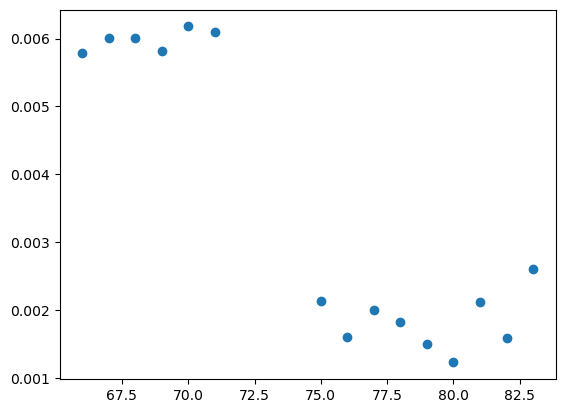

In [11]:
res.Rrs_346.plot(marker="o", linestyle="")